In [1]:
"""
IMDB Sentiment Model Analysis Script

This script:
1. Loads the trained sentiment model
2. Loads the IMDB dataset
3. Applies the same preprocessing
4. Generates predictions
5. Evaluates performance
6. Analyzes misclassified reviews
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences


# -------------------------------
# 1. Load Model
# -------------------------------

print("Loading model...")

model = tf.keras.models.load_model(
    "./models/imdb_sentiment_model.keras",
    compile=False,
    safe_mode=False
)

model.summary()


2026-03-16 02:40:38.138013: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 02:40:38.160818: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 02:40:38.160839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 02:40:38.161427: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 02:40:38.165421: I tensorflow/core/platform/cpu_feature_guar

Loading model...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          160000    
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 16)                272       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 160289 (626.13 KB)
Trainable params: 160289 (626.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-03-16 02:40:39.526859: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-16 02:40:39.548890: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-16 02:40:39.551115: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [2]:
# -------------------------------
# 2. Load Dataset
# -------------------------------

print("\nLoading IMDB dataset...")

vocab_size = 10000

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(
    num_words=vocab_size
)

print("Test samples:", len(test_data))



Loading IMDB dataset...
Test samples: 25000


In [3]:
# -------------------------------
# 3. Apply Same Preprocessing
# -------------------------------

max_length = 256

test_data = pad_sequences(
    test_data,
    value=0,
    padding="post",
    maxlen=max_length
)


In [4]:
# -------------------------------
# 4. Generate Predictions
# -------------------------------

print("\nGenerating predictions...")

predictions = model.predict(test_data)

pred_labels = (predictions > 0.5).astype(int).flatten()



Generating predictions...
782/782 [==============================] - 1s 442us/step


In [5]:
pred_labels

array([0, 1, 1, ..., 0, 0, 1])

In [6]:
# -------------------------------
# 5. Evaluation Metrics
# -------------------------------

print("\nClassification Report:\n")

print(classification_report(test_labels, pred_labels))




Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.87      0.86     12500
           1       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



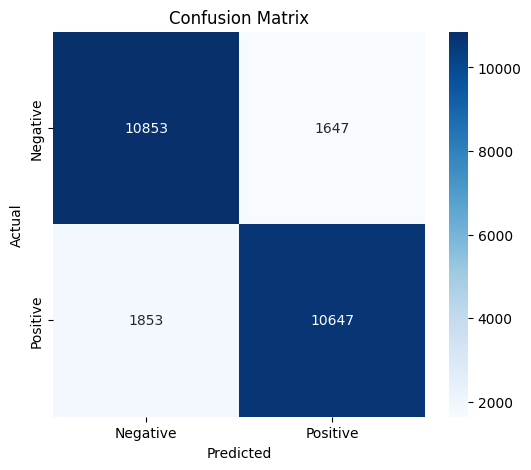

In [7]:
# -------------------------------
# 6. Confusion Matrix
# -------------------------------

cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

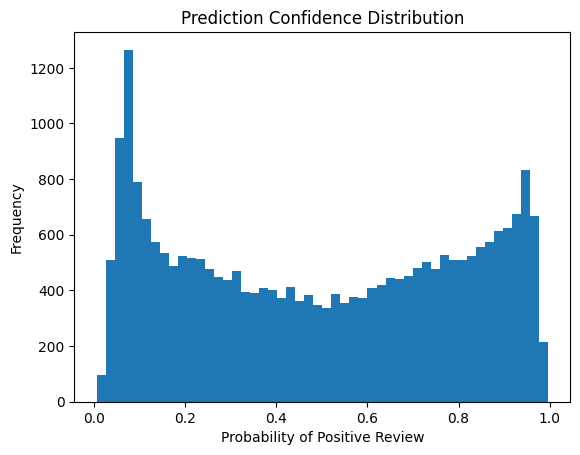

In [8]:
# -------------------------------
# 7. Prediction Confidence
# -------------------------------

plt.hist(predictions, bins=50)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability of Positive Review")
plt.ylabel("Frequency")

plt.show()

In [9]:















# -------------------------------
# 8. Decode Reviews
# -------------------------------

word_index = tf.keras.datasets.imdb.get_word_index()

reverse_word_index = {value + 3: key for key, value in word_index.items()}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"


def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])


# -------------------------------
# 9. Misclassified Reviews
# -------------------------------

misclassified = np.where(pred_labels != test_labels)[0]

print("\nTotal misclassified:", len(misclassified))


print("\nShowing 5 misclassified reviews:\n")

for i in misclassified[:5]:

    print("Actual:", test_labels[i])
    print("Predicted:", pred_labels[i])
    print("Confidence:", predictions[i][0])

    print("\nReview text:\n")

    print(decode_review(test_data[i]))

    print("\n" + "-"*80 + "\n")

1641221/1641221 [==============================] - 0s 0us/step

Total misclassified: 3500

Showing 5 misclassified reviews:

Actual: 1
Predicted: 0
Confidence: 0.40020066

Review text:

<START> i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and should be seen by all the kids in the new generation don't get to see it and i think they should it should at least be put back on the channel this movie doesn't deserve a cheap <UNK> it deserves the real thing i'm them now this movie will be on dvd <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <